In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import root_mean_squared_error as RMSE
import importlib
import linear_regressors
importlib.reload(linear_regressors)
from linear_regressors import NormalEquation, BatchGD, SGD, MiniBatchGD
import time

In [17]:
def model_fittime_error(model, X, y, cost_func):
    start = time.time()
    model.fit(X, y)
    end = time.time()
    fit_time = end - start

    pred = model.predict(X)
    score = cost_func(y, pred)
    return score, fit_time

Small Dataset

In [12]:
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)
diabetes_y = diabetes_y.reshape(-1, 1)

In [18]:
sset_NE = NormalEquation()
sset_NE_score, sset_NE_time = model_fittime_error(sset_NE, diabetes_X, diabetes_y, RMSE)

sset_BGD = BatchGD()
sset_BGD_score, sset_BGD_time = model_fittime_error(sset_BGD, diabetes_X, diabetes_y, RMSE)

sset_SGD = SGD()
sset_SGD_score, sset_SGD_time = model_fittime_error(sset_SGD, diabetes_X, diabetes_y, RMSE)

sset_MBGD = MiniBatchGD()
sset_MBGD_score, sset_MBGD_time = model_fittime_error(sset_MBGD, diabetes_X, diabetes_y, RMSE)

290
1000
1000


In [19]:
cols = ['NormalEquation', 'BatchGD', 'SGD', 'MiniBatchGD']
rows = ['RMSE', 'FitTime']
smallset_data = [
    [sset_NE_score, sset_BGD_score, sset_SGD_score, sset_MBGD_score],
    [sset_NE_time, sset_BGD_time, sset_SGD_time, sset_MBGD_time],
]

smallset_results = pd.DataFrame(smallset_data, rows, cols)
smallset_results

,NormalEquation,BatchGD,SGD,MiniBatchGD
RMSE,53.476129,53.499329,53.562921,55.200121
FitTime,0.001631,0.022942,9.823195,0.319833


Mid Dataset

In [25]:
X_housing, y_housing = datasets.fetch_california_housing(return_X_y=True)
y_housing = y_housing.reshape(-1, 1)

In [27]:
pd.DataFrame(X_housing).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20640 non-null  float64
 1   1       20640 non-null  float64
 2   2       20640 non-null  float64
 3   3       20640 non-null  float64
 4   4       20640 non-null  float64
 5   5       20640 non-null  float64
 6   6       20640 non-null  float64
 7   7       20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [29]:
mset_NE = NormalEquation()
mset_NE_score, mset_NE_time = model_fittime_error(mset_NE, X_housing, y_housing, RMSE)

mset_BGD = BatchGD()
mset_BGD_score, mset_BGD_time = model_fittime_error(mset_BGD, X_housing, y_housing, RMSE)

mset_SGD = SGD(n_epochs=100)
mset_SGD_score, mset_SGD_time = model_fittime_error(mset_SGD, X_housing, y_housing, RMSE)

mset_MBGD = MiniBatchGD()
mset_MBGD_score, mset_MBGD_time = model_fittime_error(mset_MBGD, X_housing, y_housing, RMSE)

321
100
1000


In [30]:
midset_data = [
    [mset_NE_score, mset_BGD_score, mset_SGD_score, mset_MBGD_score],
    [mset_NE_time, mset_BGD_time, mset_SGD_time, mset_MBGD_time],
]

midset_results = pd.DataFrame(midset_data, rows, cols)
midset_results

,NormalEquation,BatchGD,SGD,MiniBatchGD
RMSE,0.724100,0.724105,4.222877e+72,0.724105
FitTime,0.015165,0.390794,5.063179e+01,10.418816


Large Dataset

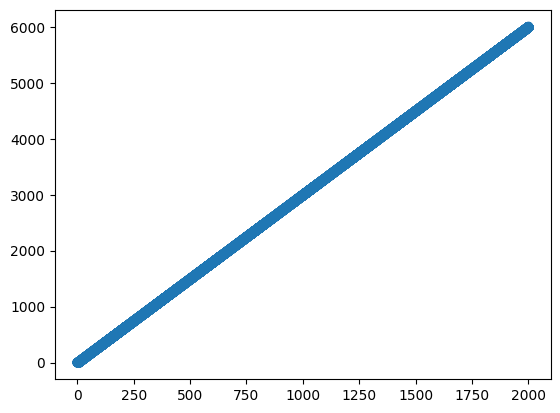

In [46]:
np.random.seed(42) # to make this code example reproducible
m = 100_000 # number of instances
X = 2 * np.random.uniform(0, 1000, size=(m, 3)) # column vector
y = (4 + 3 * X[:, 0] + np.random.randn(m)).reshape(-1, 1) # column vector

plt.scatter(X[:, 0], y.flatten())
plt.show()

In [47]:
lset_NE = NormalEquation()
lset_NE_score, lset_NE_time = model_fittime_error(lset_NE, X, y, RMSE)

lset_BGD = BatchGD(n_epochs=100)
lset_BGD_score, lset_BGD_time = model_fittime_error(lset_BGD, X, y, RMSE)

lset_SGD = SGD(n_epochs=100)
lset_SGD_score, lset_SGD_time = model_fittime_error(lset_SGD, X, y, RMSE)

lset_MBGD = MiniBatchGD(n_epochs=100)
lset_MBGD_score, lset_MBGD_time = model_fittime_error(lset_MBGD, X, y, RMSE)

100


In [48]:
largeset_data = [
    [lset_NE_score, lset_BGD_score, lset_SGD_score, lset_MBGD_score],
    [lset_NE_time, lset_BGD_time, lset_SGD_time, lset_MBGD_time],
]

largeset_results = pd.DataFrame(largeset_data, rows, cols)
largeset_results

,NormalEquation,BatchGD,SGD,MiniBatchGD
RMSE,1.001416,1.001833,1.002190,1.001417
FitTime,0.010349,0.230183,259.221327,8.669733


**summary**

In [53]:
summary = pd.concat([smallset_results, midset_results, largeset_results], axis=0)

lv1 = np.repeat(['S', 'M', 'L'], 2)
multi = pd.MultiIndex.from_arrays([lv1, summary.index.to_numpy()])

summary.index = multi
summary

NormalEquation    BatchGD           SGD  MiniBatchGD
S RMSE          53.476129  53.499329  5.356292e+01    55.200121
  FitTime        0.001631   0.022942  9.823195e+00     0.319833
M RMSE           0.724100   0.724105  4.222877e+72     0.724105
  FitTime        0.015165   0.390794  5.063179e+01    10.418816
L RMSE           1.001416   1.001833  1.002190e+00     1.001417
  FitTime        0.010349   0.230183  2.592213e+02     8.669733